In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

pd.set_option("display.float_format", "{:,.3f}".format)

In [79]:
organizations = pd.read_csv("organizations.csv")
indicator_values = pd.read_csv("indicator_values.csv")
reports = pd.read_csv("reports.csv")

print("Организаций:", organizations.shape)
print("Индикаторов:", indicator_values.shape)
print("Отчетов:", reports.shape)

Организаций: (2510, 15)
Индикаторов: (4925890, 7)
Отчетов: (300741, 7)


In [80]:
indicator_values = indicator_values[indicator_values["is_fact"] == True]
indicator_values = indicator_values.dropna(subset=["value"])

reports["accept_timestamp"] = pd.to_datetime(
    reports["accept_timestamp"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)


In [81]:
def calculate_energy_features(df):
    features = []

    for org_id, group in df.groupby("organization"):

        values = group["value"].values
        years = group["year"].values

        # пропускаем организации с малым числом наблюдений
        if len(values) < 5:
            continue

        # 1. Среднее потребление
        mean_value = float(np.mean(values))

        # 2. Стандартное отклонение
        std_value = float(np.std(values))

        # 3. Коэффициент вариации
        cv = std_value / mean_value if mean_value != 0 else 0.0

        # 4. Линейный тренд
        X_year = years.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X_year, values)
        trend = float(model.coef_[0])

        # 5. Доля аномальных изменений
        anomalies = np.sum(np.abs(values - mean_value) > 3 * std_value)
        anomaly_share = anomalies / len(values)

        # Добавляем округлённые значения
        features.append({
            "organization": org_id,
            "mean_energy": round(mean_value, 3),
            "trend_energy": round(trend, 3),
            "cv_energy": round(cv, 3),
            "anomaly_share": round(anomaly_share, 3)
        })

    result_df = pd.DataFrame(features)

    # дополнительная гарантия округления
    result_df = result_df.round(3)

    return result_df


energy_features = calculate_energy_features(indicator_values)

energy_features.head()

,organization,mean_energy,trend_energy,cv_energy,anomaly_share
0,1,"14,087,758.991","-112,481.160",5.702,0.010
1,2,"1,468,537.503","-195,376.899",23.856,0.002
2,3,"141,505.084","-24,032.901",5.378,0.014
3,4,"6,530.834",-630.841,19.671,0.002
4,6,"13,816.218",-631.767,6.275,0.010


In [82]:
def get_deadline(year, quarter):

    if pd.isna(year):
        return None

    if pd.isna(quarter):
        quarter = 4

    year = int(year)
    quarter = int(quarter)

    if quarter == 1:
        return pd.Timestamp(year=year, month=4, day=30)
    elif quarter == 2:
        return pd.Timestamp(year=year, month=7, day=31)
    elif quarter == 3:
        return pd.Timestamp(year=year, month=10, day=31)
    else:
        return pd.Timestamp(year=year + 1, month=1, day=31)


discipline_features = []

for org_id, group in reports.groupby("src_organization"):

    total = len(group)
    if total == 0:
        continue

    timely = 0

    for _, row in group.iterrows():

        if pd.isna(row["accept_timestamp"]):
            continue

        deadline = get_deadline(row["year"], row["quarter"])
        if deadline is None:
            continue

        if row["accept_timestamp"] <= deadline:
            timely += 1

    discipline_features.append({
        "organization": org_id,
        "report_timeliness": timely / total if total > 0 else 0,
        "series_length": group["year"].dropna().nunique()
    })

discipline_features = pd.DataFrame(discipline_features)
discipline_features.head()

,organization,report_timeliness,series_length
0,1,0.083,16
1,2,0.211,13
2,3,0.284,12
3,4,0.270,13
4,6,0.274,12


In [83]:
dataset = energy_features.merge(
    discipline_features,
    on="organization",
    how="inner"
)

# Удаляем строки с пропусками
dataset = dataset.dropna()

# Округляем все числовые столбцы до 3 знаков
numeric_cols = dataset.select_dtypes(include=["float64", "int64"]).columns
dataset[numeric_cols] = dataset[numeric_cols].round(3)

print("Финальный датасет:", dataset.shape)

dataset.head()

Финальный датасет: (2013, 7)


,organization,mean_energy,trend_energy,cv_energy,anomaly_share,report_timeliness,series_length
0,1,"14,087,758.991","-112,481.160",5.702,0.010,0.083,16
1,2,"1,468,537.503","-195,376.899",23.856,0.002,0.211,13
2,3,"141,505.084","-24,032.901",5.378,0.014,0.284,12
3,4,"6,530.834",-630.841,19.671,0.002,0.270,13
4,6,"13,816.218",-631.767,6.275,0.010,0.274,12


<Figure size 1200x800 with 0 Axes>

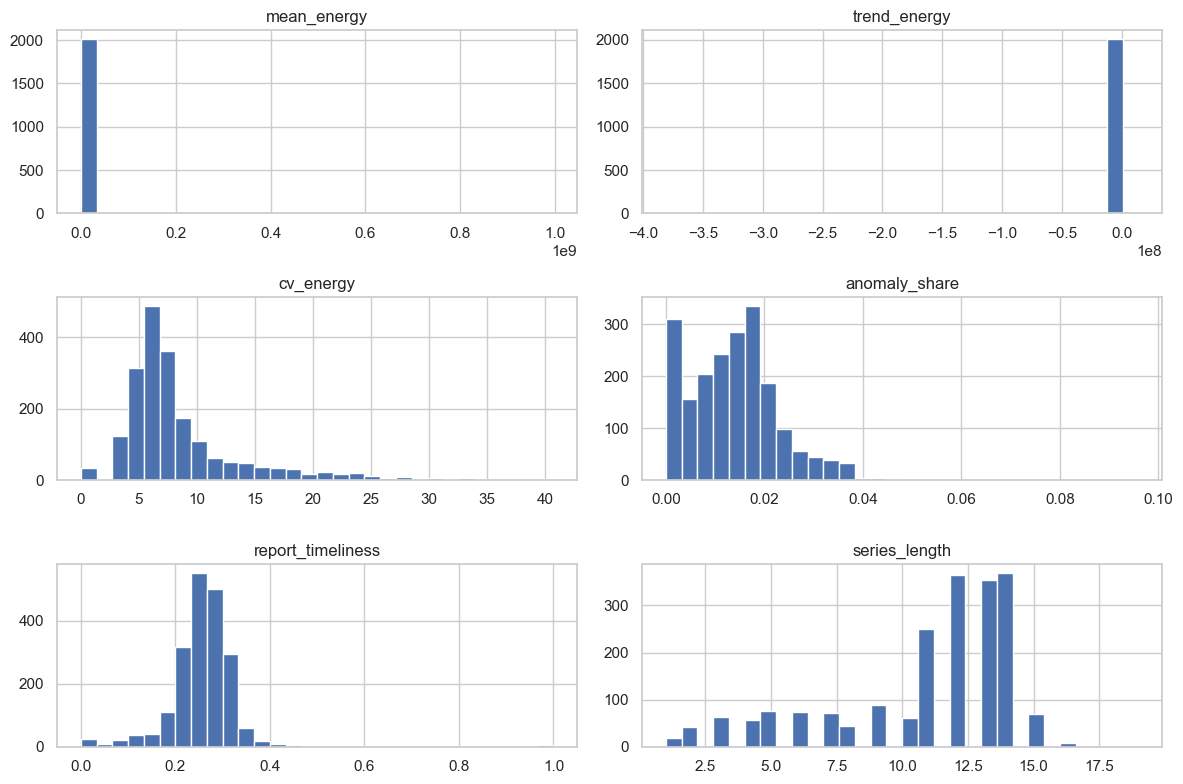

In [84]:
dataset.describe()

plt.figure(figsize=(12,8))
dataset.drop(columns=["organization"]).hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [85]:
X = dataset.drop(columns=["organization"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

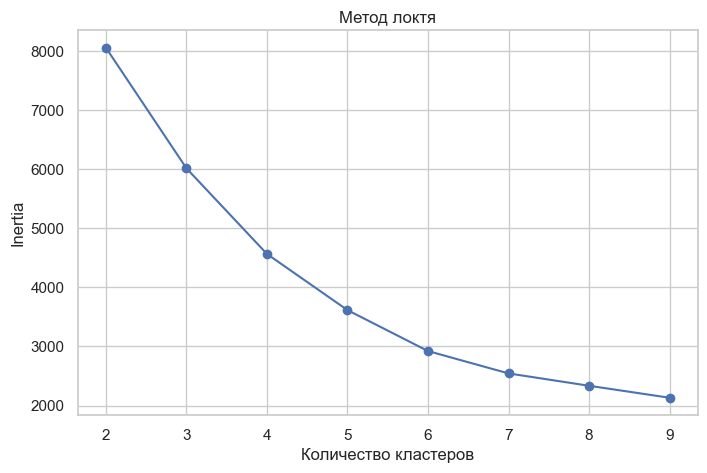

In [86]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker="o")
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.show()

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

dataset["cluster"] = labels

# Округляем числовые столбцы
numeric_cols = dataset.select_dtypes(include=["float64", "int64"]).columns
dataset[numeric_cols] = dataset[numeric_cols].round(3)

print("\nПервые строки итогового датасета:")
display(dataset.head())


Первые строки итогового датасета:


,organization,mean_energy,trend_energy,cv_energy,anomaly_share,report_timeliness,series_length,cluster
0,1,"14,087,758.991","-112,481.160",5.702,0.010,0.083,16,0
1,2,"1,468,537.503","-195,376.899",23.856,0.002,0.211,13,3
2,3,"141,505.084","-24,032.901",5.378,0.014,0.284,12,0
3,4,"6,530.834",-630.841,19.671,0.002,0.270,13,3
4,6,"13,816.218",-631.767,6.275,0.010,0.274,12,0


In [88]:
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("\nМетрики качества:")
print("Silhouette Score:", round(sil, 3))
print("Davies–Bouldin Index:", round(dbi, 3))
print("Calinski–Harabasz Index:", round(ch, 3))



Метрики качества:
Silhouette Score: 0.406
Davies–Bouldin Index: 0.907
Calinski–Harabasz Index: 1101.135


In [89]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=X.columns
)

centroids_df["cluster"] = range(len(centroids_df))

# Округляем центроиды
centroids_df = centroids_df.round(3)

print("\nЦентроиды кластеров:")
display(centroids_df)


Центроиды кластеров:


,mean_energy,trend_energy,cv_energy,anomaly_share,report_timeliness,series_length,cluster
0,"81,785.849","-5,873.331",6.822,0.015,0.265,12.467,0
1,"88,787.853","-6,580.016",5.836,0.020,0.234,5.108,1
2,"996,228,192.668","-380,973,657.889",34.007,0.001,0.287,11.000,2
3,"698,978.025","-14,957.122",19.290,0.002,0.262,11.380,3


In [90]:
cluster_sizes = dataset["cluster"].value_counts().reset_index()
cluster_sizes.columns = ["cluster", "count"]
cluster_sizes

,cluster,count
0,0,1267
1,1,408
2,3,337
3,2,1


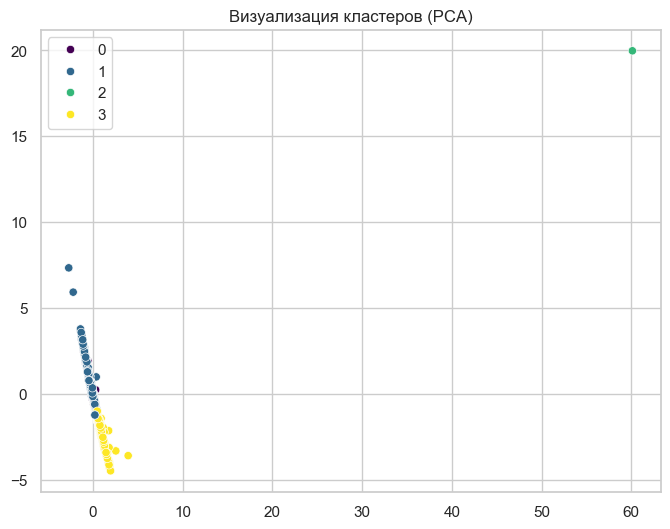

In [91]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="viridis")
plt.title("Визуализация кластеров (PCA)")
plt.show()

In [92]:
scores = []

for seed in range(5):
    model = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels_tmp = model.fit_predict(X_scaled)
    sil_tmp = silhouette_score(X_scaled, labels_tmp)
    scores.append(sil_tmp)

# Округляем значения
scores_rounded = [round(s, 3) for s in scores]
mean_score = round(np.mean(scores), 3)

print("Silhouette при разных random_state:", scores_rounded)
print("Среднее значение:", mean_score)

Silhouette при разных random_state: [0.406, 0.406, 0.406, 0.406, 0.406]
Среднее значение: 0.406


In [93]:
org_filtered = organizations.copy()

# Удаляем архивные (если поле есть)
if "archived" in org_filtered.columns:
    org_filtered = org_filtered[org_filtered["archived"] == False]

# Удаляем ликвидированные
org_filtered = org_filtered[
    ~org_filtered["name"].str.contains("ЛИКВИД", case=False, na=False)
]

# Удаляем тестовые
org_filtered = org_filtered[
    ~org_filtered["name"].str.contains("ТЕСТ", case=False, na=False)
]

print("После фильтрации организаций:", org_filtered.shape)


После фильтрации организаций: (2235, 15)


In [106]:

if "short_name" in org_filtered.columns:
    org_filtered["display_name"] = org_filtered["short_name"].fillna(org_filtered["name"])
else:
    org_filtered["display_name"] = org_filtered["name"]

org_names = org_filtered[["id", "display_name"]]
org_names.columns = ["organization", "org_name"]

ip_agg = ip_agg.merge(org_names, on="organization", how="left")

valid_ids = org_filtered["id"].unique()

indicator_values_filtered = indicator_values[
    indicator_values["organization"].isin(valid_ids)
]

print(ip_agg.columns)


Index(['organization', 'IP10', 'IP13', 'IP16', 'IP20', 'IP7', 'total_energy',
       'org_name'],
      dtype='object')


In [104]:
selected_ips = ["IP7", "IP10", "IP13", "IP16", "IP20"]

ip_subset = indicator_values_filtered[
    indicator_values_filtered["code"].isin(selected_ips)
]

ip_agg = (
    ip_subset
    .groupby(["organization", "code"])["value"]
    .mean()
    .unstack()
    .reset_index()
)

In [107]:
ip_agg["total_energy"] = ip_agg[selected_ips].fillna(0).sum(axis=1)
ip_agg = ip_agg[ip_agg["total_energy"] > 0]

ip_agg_sorted = ip_agg.sort_values("total_energy", ascending=False)

top_20 = ip_agg_sorted.head(20).copy()
bottom_20 = ip_agg_sorted.tail(20).copy()

display(top_20[["org_name", "total_energy"]])
display(bottom_20[["org_name", "total_energy"]])

,org_name,total_energy
928,"ГБОУ ЛО ""Сланцевское специальное учебно-воспит...","4,605,427,095.422"
128,ГБУЗ ЛО,"10,568,127.580"
139,ГБУЗ ЛОКБ,"3,537,645.977"
219,"ГБУЗ ЛО ""ВОЛХОВСКАЯ МБ""","2,388,091.886"
108,"ГБУЗ ЛО ""ГАТЧИНСКАЯ КМБ""","2,286,760.746"
1407,"ЛО ГБУ ""Недвижимость""","2,175,905.910"
218,"ГБУЗ ЛО ""ВСЕВОЛОЖСКАЯ КМБ""","2,020,042.884"
611,"ГАУ ЛО ""СТЦ ЛО""","1,714,405.408"
1050,ГБУЗ ЛО Тихвинская МБ,"1,564,877.369"
1165,МАУ «ОЛИМП»,"1,348,307.889"


,org_name,total_energy
836,МКОУДО АННИНСКАЯ ДШИ,62.123
607,МУДО «Сланцевский центр психолого-педагогическ...,55.516
1281,МКУ «Центр диагностики и консультирования»,50.500
556,ЛОГКУ Леноблэкомилиция,50.017
631,"МКУ ""СЗ"" БГП",48.179
1329,МБУ «Пудомягский КДЦ»,47.276
6,"ГКУ ЛО ""ЦЭПЭ ЛО""",30.235
1381,"МКУ ""Центр образования Волховского района""",24.144
1367,МКУ «ГИЦ»,15.799
1184,БМУ «Токсовская служба заказчика»,12.352


In [108]:
# Кластеризация по IP

X_ip = ip_agg[selected_ips].fillna(0)

scaler_ip = StandardScaler()
X_ip_scaled = scaler_ip.fit_transform(X_ip)

kmeans_ip = KMeans(n_clusters=3, random_state=42, n_init=10)
ip_labels = kmeans_ip.fit_predict(X_ip_scaled)

ip_agg["energy_cluster"] = ip_labels


# Средние значения по кластерам (числовые)
cluster_summary = (
    ip_agg
    .groupby("energy_cluster")["total_energy"]
    .mean()
    .round(3)
    .sort_values()
)

# Форматирование для красивого вывода
cluster_summary_display = cluster_summary.map(lambda x: f"{x:,.3f}")

print("\nСредние значения total_energy по 3 кластерам:")
display(cluster_summary_display)


Средние значения total_energy по 3 кластерам:


energy_cluster
0           91,425.845
1        1,922,000.090
2    4,605,427,095.422
Name: total_energy, dtype: object